In [1]:

import pandas as pd

In [2]:

df = pd.read_csv('protein.csv')

df.head()

,Country,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
0,Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
1,Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
2,Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
3,Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
4,Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [3]:

X2 = df.iloc[:,1:]

In [4]:

X2

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
0,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
1,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
2,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
3,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
4,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0
5,10.6,10.8,3.7,25.0,9.9,21.9,4.8,0.7,2.4
6,8.4,11.6,3.7,11.1,5.4,24.6,6.5,0.8,3.6
7,9.5,4.9,2.7,33.7,5.8,26.3,5.1,1.0,1.4
8,18.0,9.9,3.3,19.5,5.7,28.1,4.8,2.4,6.5
9,10.2,3.0,2.8,17.6,5.9,41.7,2.2,7.8,6.5


In [5]:

from scipy.cluster.hierarchy import dendrogram, linkage

In [7]:

linkage(X2, method='ward')

array([[ 5.        , 19.        ,  4.79583152,  2.        ],
       [ 3.        , 24.        ,  4.8754487 ,  2.        ],
       [11.        , 20.        ,  5.09705797,  2.        ],
       [ 2.        ,  8.        ,  6.00749532,  2.        ],
       [13.        , 23.        ,  6.52533524,  2.        ],
       [14.        , 25.        ,  6.5380935 ,  3.        ],
       [21.        , 28.        ,  7.184474  ,  3.        ],
       [ 9.        , 12.        ,  7.97684148,  2.        ],
       [ 4.        , 15.        ,  8.25530133,  2.        ],
       [17.        , 26.        ,  8.38033412,  3.        ],
       [16.        , 18.        ,  8.78862902,  2.        ],
       [22.        , 32.        ,  9.1124457 ,  3.        ],
       [ 1.        , 29.        ,  9.20543318,  3.        ],
       [27.        , 37.        , 10.29970873,  5.        ],
       [10.        , 33.        , 11.37292106,  3.        ],
       [ 0.        , 36.        , 12.42148676,  4.        ],
       [ 7.        , 30.


method='ward' → specifies the linkage criterion:

    Ward’s method minimizes the variance within clusters when merging them.

    It tends to produce clusters of similar size, and is usually preferred for numerical data.
    


Each row corresponds to one merge.

Columns in the output:

    Index of cluster 1 being merged
    
    Index of cluster 2 being merged
    
    Distance (or dissimilarity) between them
    
    Number of points in the new cluster formed
    


From your matrix, the first row is:  [ 5. , 19. ,  4.7958 ,  2. ]


Interpretation:

    Observation 5 and 19 are merged.

    Their distance = 4.796.

    The new cluster contains 2 points.
    

| Position | Meaning                  | Explanation                                                                       |
| -------- | ------------------------ | --------------------------------------------------------------------------------- |
| `5`      | Cluster/observation ID 1 | Refers to the **6th observation** (index 5, since Python uses 0-based indexing).  |
| `19`     | Cluster/observation ID 2 | Refers to the **20th observation** (index 19).                                    |
| `4.7958` | Distance                 | The **linkage distance** (e.g., Euclidean distance) between observation 5 and 19. |
| `2`      | Number of samples        | The **newly formed cluster** now contains **2 points** (those two observations).  |



The last row:  [45. , 47. , 72.2598 , 25. ]

Interpretation:

    Cluster 45 (formed earlier) and cluster 47 (formed earlier) are merged.
    
    Their distance = 72.26 (biggest jump → final merge).
    
    New cluster contains 25 points → i.e. all data points (so your dataset had 25 rows).
    

In [8]:
#Z2 = linkage(X2, method='ward', metric='euclidean')

Z2 = linkage(X2, method='ward')   # Euclidean is implicit


In [9]:

labelList = list(df['Country'])

print(labelList)

['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Czechoslovakia', 'Denmark', 'E.Germany', 'Finland', 'France', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Spain', 'Sweden', 'Switzerland', 'UK', 'USSR', 'W.Germany', 'Yugoslavia']


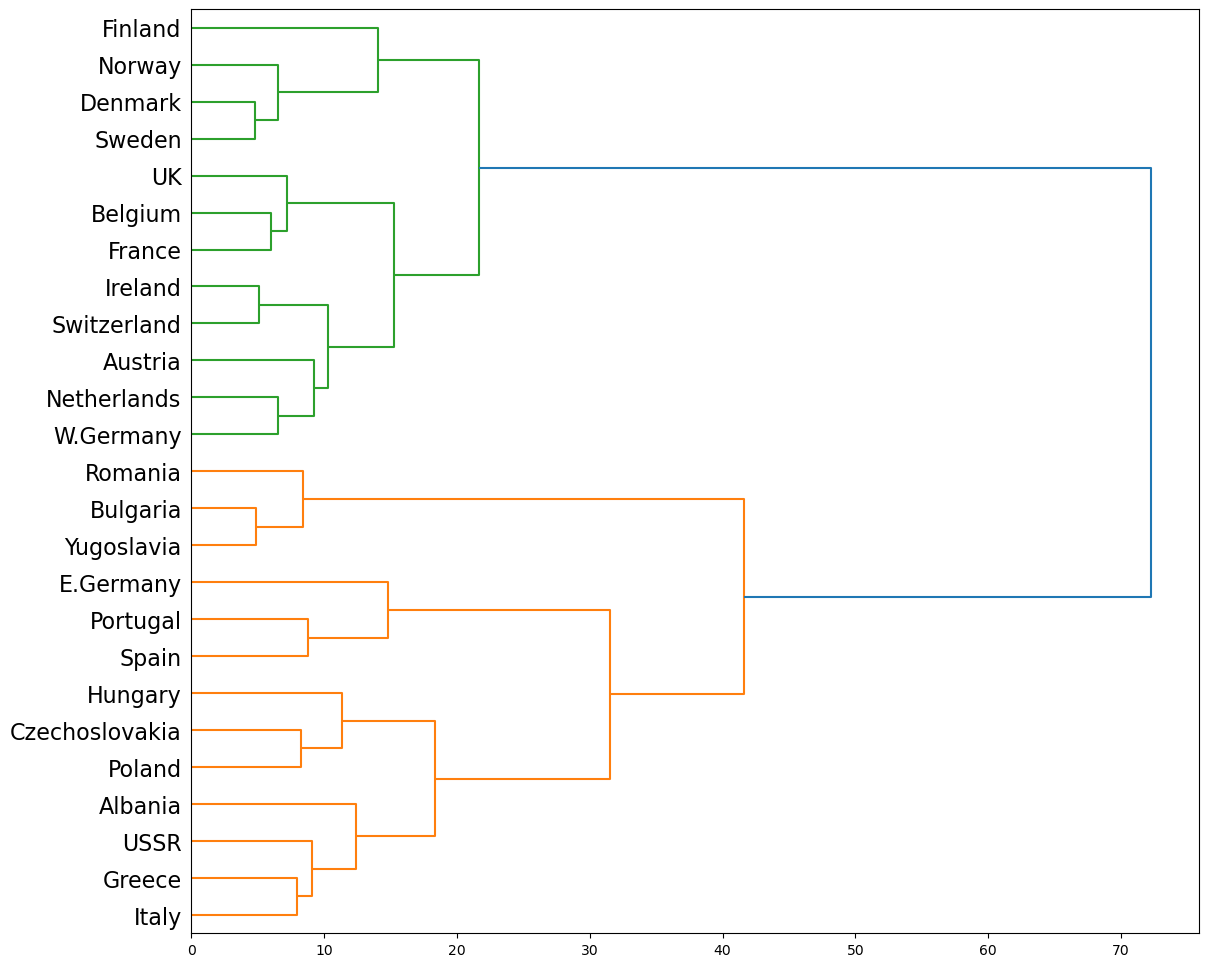

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 12))
dendrogram(
    Z2,
    orientation='right',
    labels=labelList,
    distance_sort='descending',
    show_leaf_counts=False,
    leaf_font_size=16
)
plt.show()


Options for orientation

    "top" (default) → tree grows downwards (distance on the y-axis).
    
    "right" → tree grows left-to-right (distance on the x-axis, labels on the y-axis).
    
    "left" → tree grows right-to-left (distance on the x-axis, labels on the y-axis).
    
    "bottom" → tree grows upwards (distance on the y-axis).

distance_sort='descending'

Controls how merges at the same distance are ordered.

Options:

    "ascending" → smallest distances appear first.
    
    "descending" → largest distances appear first.
    
    False (default) → don’t sort, just show in the order computed.

In [11]:

from scipy.cluster.hierarchy import fcluster

In [12]:

df['Clusters'] = fcluster(Z2, 2, criterion='maxclust')

df.head(20)


,Country,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg,Clusters
0,Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7,2
1,Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3,1
2,Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0,1
3,Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2,2
4,Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0,2
5,Denmark,10.6,10.8,3.7,25.0,9.9,21.9,4.8,0.7,2.4,1
6,E.Germany,8.4,11.6,3.7,11.1,5.4,24.6,6.5,0.8,3.6,2
7,Finland,9.5,4.9,2.7,33.7,5.8,26.3,5.1,1.0,1.4,1
8,France,18.0,9.9,3.3,19.5,5.7,28.1,4.8,2.4,6.5,1
9,Greece,10.2,3.0,2.8,17.6,5.9,41.7,2.2,7.8,6.5,2


### best separation (highest silhouette score).

In [13]:

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

scores = {}
for k in range(2, 11):  
    labels = fcluster(Z2, k, criterion='maxclust')
    score = silhouette_score(X2, labels)
    scores[k] = score

print(scores)


{2: 0.3937984114369407, 3: 0.36001142808555486, 4: 0.3821282383613303, 5: 0.29500298699763905, 6: 0.2783958993667076, 7: 0.26701856227914894, 8: 0.26051591616843495, 9: 0.27267011797135526, 10: 0.25422732265923864}


In [14]:

best_k = max(scores, key=scores.get)

print(f"Optimal number of clusters (by silhouette) = {best_k}")


Optimal number of clusters (by silhouette) = 2


### Plot silhouette score vs k

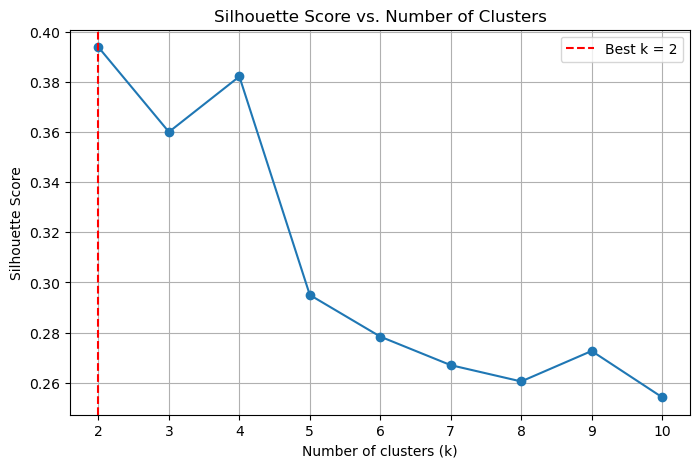

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.grid(True)

# Highlight the best k
plt.axvline(x=best_k, color='red', linestyle='--', label=f"Best k = {best_k}")
plt.legend()
plt.show()
